In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.preprocessing import PolynomialFeatures

## Libraries Used

Pandas is used to load and handle the dataset, NumPy for numerical and matrix operations, Matplotlib for plotting the cross-validation results, KFold for 5-fold cross-validation, and PolynomialFeatures for generating polynomial and interaction terms.

In [8]:
# Load data
train_df = pd.read_csv("BT2024085_train_var1.csv")
test_df = pd.read_csv("BT2024085_test_var1.csv")

print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)


# Separate features and target
features = ["x1", "x2", "x3","x4","x5","x6"]
X = train_df[features].values
y = train_df["y"].values
X_test = test_df[features].values

Training shape: (1000, 7)
Test shape: (1000, 6)


## Polynomial Feature Generation

Polynomial features are used to model nonlinear relationships between the input features and the target. PolynomialFeatures generates the required polynomial and interaction terms up to the selected degree.

In [9]:
# Create polynomial features
def make_polynomial_features(X_train, X_val, degree):
    poly = PolynomialFeatures(degree=degree,include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.transform(X_val)
    return X_train_poly, X_val_poly, poly

## Ridge Regression

Ridge regression applies L2 regularization to control the magnitude of the model coefficients. This is useful for polynomial models because increasing the degree creates more features and can introduce correlated terms. The intercept is not regularized.

In [10]:
# Calculate Ridge weights
def calculate_ridge_weights(X, y, alpha):
    X_bias = np.column_stack((np.ones(X.shape[0]), X))
    n_features = X_bias.shape[1]
    I = np.eye(n_features)
    I[0, 0] = 0
    weights = np.linalg.solve(X_bias.T @ X_bias + alpha * I,X_bias.T @ y)
    return weights

## Model Evaluation

MSE measures the average squared prediction error, where a lower value indicates better performance. R² measures the proportion of variation in the target explained by the model, where a higher value generally indicates better performance.

In [11]:
# Make predictions
def predict(X, weights):
    X_bias = np.column_stack((np.ones(X.shape[0]), X))
    return X_bias @ weights

# Calculate MSE
def calculate_mse(y, y_pred):
    return np.mean((y - y_pred) ** 2)

# Calculate R2
def calculate_r2(y, y_pred):
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - (ss_res / ss_tot)

## Model Selection using 5-Fold Cross-Validation

5-fold cross-validation is used to evaluate the models on different validation subsets of the training data. For each polynomial degree, different Ridge α values are tested, and the α giving the lowest mean CV MSE is selected. The degree with the lowest resulting CV MSE is selected as the best model.

In [12]:
# Setup 5-fold cross validation
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# Alpha values to test
alphas = [1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1,10]
# Test degrees from 1 to 10
results = []

In [13]:
for degree in range(1, 11):
    best_degree_mse = float("inf")
    best_degree_r2 = None
    best_degree_alpha = None
    # Try different alpha values
    for alpha in alphas:
        mse_values = []
        r2_values = []
        # Perform 5-fold cross validation
        for train_index, val_index in kf.split(X):
            # Split training and validation data
            X_train = X[train_index]
            y_train = y[train_index]
            X_val = X[val_index]
            y_val = y[val_index]
            # Create polynomial features
            X_train_poly,X_val_poly,poly = make_polynomial_features(X_train,X_val,degree)
            # Calculate Ridge weights
            weights = calculate_ridge_weights(X_train_poly,y_train,alpha)
            # Predict validation data
            y_val_pred = predict(X_val_poly,weights)
            # Calculate validation metrics
            fold_mse = calculate_mse(y_val,y_val_pred)
            fold_r2 = calculate_r2(y_val,y_val_pred)
            mse_values.append(fold_mse)
            r2_values.append(fold_r2)

        # Average CV metrics
        mean_mse = np.mean(mse_values)
        mean_r2 = np.mean(r2_values)
        # Keep best alpha for this degree
        if mean_mse < best_degree_mse:
            best_degree_mse = mean_mse
            best_degree_r2 = mean_r2
            best_degree_alpha = alpha
    # Store best result for this degree
    results.append((degree,best_degree_mse,best_degree_r2,best_degree_alpha))
    # Print CV results
    print(f"Degree {degree:2d} | "f"CV MSE: {best_degree_mse:.4f} "f"(R2: {best_degree_r2:.4f}) | "f"Alpha: {best_degree_alpha:.0e}")

Degree  1 | CV MSE: 8.7948 (R2: 0.1122) | Alpha: 1e+01
Degree  2 | CV MSE: 3.1228 (R2: 0.6783) | Alpha: 1e+00
Degree  3 | CV MSE: 0.9780 (R2: 0.8998) | Alpha: 1e+00
Degree  4 | CV MSE: 0.7697 (R2: 0.9204) | Alpha: 1e+00
Degree  5 | CV MSE: 0.5300 (R2: 0.9450) | Alpha: 1e+00
Degree  6 | CV MSE: 0.6114 (R2: 0.9370) | Alpha: 1e+01
Degree  7 | CV MSE: 0.5811 (R2: 0.9401) | Alpha: 1e+01
Degree  8 | CV MSE: 0.6795 (R2: 0.9297) | Alpha: 1e+01
Degree  9 | CV MSE: 0.7121 (R2: 0.9262) | Alpha: 1e+01
Degree 10 | CV MSE: 0.8099 (R2: 0.9158) | Alpha: 1e+01


## Cross-Validation Results

The CV MSE and CV R² are plotted against polynomial degree to observe how model performance changes as the complexity of the polynomial model increases.

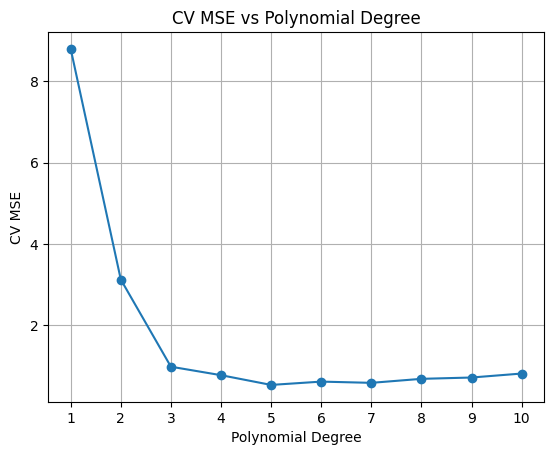

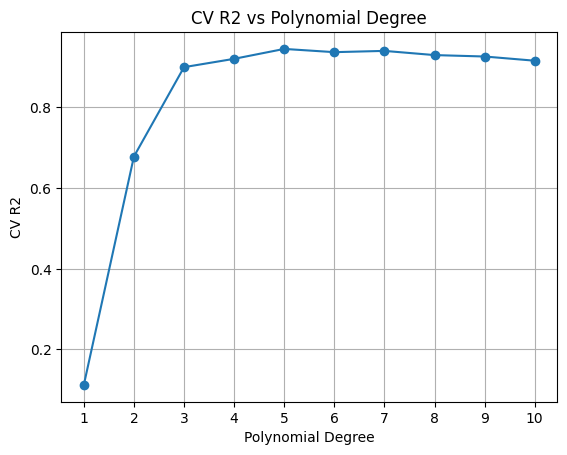

In [14]:
# Plot CV MSE and CV R2
degrees = [r[0] for r in results]
cv_mse = [r[1] for r in results]
cv_r2 = [r[2] for r in results]


# CV MSE graph
plt.figure()
plt.plot(
    degrees,
    cv_mse,
    marker="o"
)
plt.xlabel("Polynomial Degree")
plt.ylabel("CV MSE")
plt.title("CV MSE vs Polynomial Degree")
plt.xticks(degrees)
plt.grid(True)
plt.show()


# CV R2 graph
plt.figure()
plt.plot(
    degrees,
    cv_r2,
    marker="o"
)
plt.xlabel("Polynomial Degree")
plt.ylabel("CV R2")
plt.title("CV R2 vs Polynomial Degree")
plt.xticks(degrees)
plt.grid(True)
plt.show()

## Final Model

After selecting the best polynomial degree and Ridge α using cross-validation, the model is retrained using the complete training dataset. The final model is then used to generate predictions for the test dataset.

In [15]:
# Select best degree and alpha
best_degree, best_mse, best_r2, best_alpha = min(results,key=lambda x: x[1])
print("\nBest Degree:", best_degree)
print("Best CV MSE:", best_mse)
print("Best CV R2:", best_r2)
print("Best Alpha:", best_alpha)

# Train final model using all training data
poly = PolynomialFeatures(degree=best_degree,include_bias=False)
X_poly = poly.fit_transform(X)
X_test_poly = poly.transform(X_test)

# Calculate final Ridge weights
weights = calculate_ridge_weights(X_poly,y,best_alpha)

# Calculate final training performance
y_train_pred = predict(X_poly,weights)
train_mse = calculate_mse(y,y_train_pred)

train_r2 = calculate_r2(y,y_train_pred)

print("\nFinal Training MSE:", train_mse)
print("Final Training R2:", train_r2)


Best Degree: 5
Best CV MSE: 0.5299800269179802
Best CV R2: 0.9449756680600142
Best Alpha: 1

Final Training MSE: 0.16330551053332412
Final Training R2: 0.9834705439919651


In [17]:
# Predict test data
y_test_pred = predict(X_test_poly,weights)
# Save predictions
submission = pd.DataFrame({"y": y_test_pred})
submission.to_csv("BT2024085_pred_var1.csv",index=False)
print("\nPredictions saved to:")
print("BT2024085_pred_var1.csv")


Predictions saved to:
BT2024085_pred_var1.csv
